
## Impr-U-ving Image Segmentation: Comparing Autoencoders and U-Nets

#### Rhiannon Morris
#### College of Natural Science, The University of Texas at Austin

### Subsurface Machine Learning Course, The University of Texas at Austin
#### Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering
#### Department of Geological Sciences, Jackson School of Geosciences

_____________________

Workflow supervision and review by:

#### Instructor: Prof. Michael Pyrcz, Ph.D., P.Eng., Associate Professor, The Univeristy of Texas at Austin
[Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)

#### Course TA: Elnara Rustamzade, Graduate Student, The University of Texas at Austin
##### [LinkedIn](https://www.linkedin.com/in/elnara-rustamzade/)


### Executive Summary

Autoencoders are commonly used in industry for dimensionality reduction, including image
denoising in computer vision. However, important spatial details can be lost during the compression phase, leading to poor image segmentation.
In 2015, Ronneberger, Fischer, & Brox suggested the "U-Net", an architecture that incorporated "skip connections" into an autoencoder to preserve spatial information.

A simple U-net and autoencoder were constructed to compare the effectiveness of each architecture on the same task. Results show that a simple U-Net outperforms its autoencoder counterpart for pixel accuracy, cross-entropy loss, and Instersection over Union (IoU).
It is recommended that U-Nets be used for precise image segmentation tasks, including identification of cross-image patterns in geographical spectral data or precise spatial detection of tumors in cancer imaging.

### Background

Provided is the diagram of the proposed U-Net architecure from Ronneberger, Fischer & Brox's 2015 paper "U-Net: Convolutional Networks for Biomedical Image Segmentation".

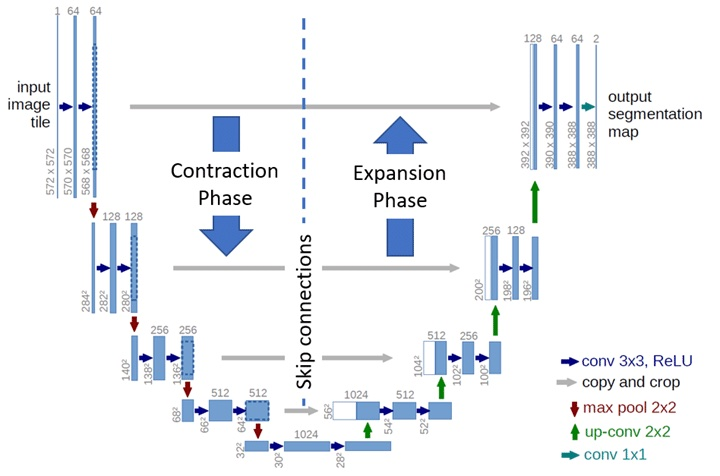

*Ronneberger, O., Fischer, P., Brox, T. (2015). U-Net: Convolutional Networks for Biomedical Image Segmentation. In: Navab, N., Hornegger, J., Wells, W., Frangi, A. (eds) Medical Image Computing and Computer-Assisted Intervention – MICCAI 2015. MICCAI 2015. Lecture Notes in Computer Science(), vol 9351. Springer, Cham. https://doi.org/10.1007/978-3-319-24574-4_28*

The U-Net follows a similar structure as a traditional autoencoder (encoder, bottleneck, decoder), but also includes horizontal skip connections. These connections reintroduce spatial information (sharp boundaries, edges, etc.) into the decoder during upsampling by concatenating features directly.

### Import Packages

The following packages and libraries are required for the workflow.

In [1]:
!pip install torchmetrics

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import OxfordIIITPet
import torchvision.transforms as T
from PIL import Image
import numpy as np
from torchmetrics import JaccardIndex #For IoU calculation

### Load Data

The following code willl allow for GPU usage while running the pytorch model. It is recommended to use GPU to reduce computational time, but CPU will be the default if this is not possible.

In [3]:
#Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


The data will need preprocessing to ensure all images are of a predetermined pixel size and are compatible with pytorch. This includes converting image segmentation masks to integers.

An image segmentation mask is a labeled map that classifies each pixel (foreground, background, outline/border). These masks are essential for propoer U-Net modeling.

This workflow is designed specifically for a dataset that already has precomputed segmentation masks in addition to the original image.

In [4]:
#Determine how images are preprocessed before going into the model
image_transforms = T.Compose([
    T.Resize((256,256)), #Pixels to 256 to extract high-quality images
    T.ToTensor(), #Need to convert images to tensors to be compatible with pytorch
])

#With the help of Perplexity, image masks were converted to integers compatible with CrossEntropyLoss
def mask_transform(mask: Image.Image):
    mask = mask.resize((256,256), resample=Image.NEAREST) #Class IDs have to be whole numbers, NEAREST prevents partial numbers (classes are 0,1,2,etc.)
    mask = np.array(mask, dtype=np.int64)
    mask = mask - 1  # Labels in this dataset start with 1, but PyTorch expects labels that start with 0
    mask = np.clip(mask, 0, 2) #ensures there are only 3 classes (0,1,2) for CrossEntropy loss function
    return torch.from_numpy(mask).long() #Will be using a CrossEntropyLoss fxn later and need to ensure correct datatype input

The following workflow uses the open-source [OxfordIIITPet dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/), comprised of 7,400 RGB images of pets with 37 classes (pet breeds) and roughly 200 images per class.

To prevent computational overload, we will be taking a small subset of the dataset. The following workflow is for educational purposes. Typically, you should not use such a small data set.

In [5]:
#Load Data
#https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.OxfordIIITPet.html
data = OxfordIIITPet(
    root="./data",
    download=True,
    target_types="segmentation",
    transform=image_transforms,
    target_transform=mask_transform,
)

#Create a small subset as this is for educational purposes and the entire dataset will be computationally extensive
subset_size = 250
small_subset, extradata = random_split(data, [subset_size, len(data)-subset_size]) #This randomly selects 250 images and the rest is extra.

#Split 80/20
train_size = int(0.8 * subset_size)
val_size = subset_size - train_size
train_set, val_set = random_split(small_subset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=2, shuffle=True)
val_loader = DataLoader(val_set, batch_size=2)

### Simple U-Net Construction

The folowing simple U-Net was bassed off of the U-Net architecture outlined in Ronneberger, Fischer, & Brox's 2015 paper (included above).

In [6]:
#https://docs.pytorch.org/docs/main/nn.html
#Create the Convolution block
class Convolution(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)

#Down the U-Net (Encoder steps)
class Encoderstep(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.convsteps = Convolution(in_channels, out_channels)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        x_conv = self.convsteps(x)
        x_pooled = self.pool(x_conv)
        return x_conv, x_pooled

#Up the U-Net (Decoder steps)
class Decoderstep(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.upsample = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.convsteps = Convolution(out_channels * 2, out_channels) # *2 tto incorporate concatenation of kip channels
    #the following forward pass was modified by perplexity to fix CUDA assertion error
    def forward(self, x, skip):
        x = self.upsample(x)
        # If any size mismatch happens due to pooling/upsampling, center-crop skip
        if x.shape[-2:] != skip.shape[-2:]:
            dh = skip.shape[-2] - x.shape[-2]
            dw = skip.shape[-1] - x.shape[-1]
            skip = skip[
                ...,
                dh // 2 : skip.shape[-2] - (dh - dh // 2),
                dw // 2 : skip.shape[-1] - (dw - dw // 2),
            ]
        x = torch.cat([x, skip], dim=1)
        x = self.convsteps(x)
        return x

#Building the U-Net
class SimpleUNet(nn.Module):
    def __init__(self, n_classes=3):
        super().__init__()
        # Encoder
        self.enstep1 = Encoderstep(3, 16)
        self.enstep2 = Encoderstep(16, 32)
        self.enstep3 = Encoderstep(32, 64)
        self.enstep4 = Encoderstep(64, 128)
        # Bottleneck
        self.bottleneck = Convolution(128, 256)
        # Decoder
        self.destep1 = Decoderstep(256, 128)
        self.destep2 = Decoderstep(128, 64)
        self.destep3 = Decoderstep(64, 32)
        self.destep4 = Decoderstep(32, 16)
        # Final predictive layer
        self.final = nn.Conv2d(16, n_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        skip1, pooled1 = self.enstep1(x)
        skip2, pooled2 = self.enstep2(pooled1)
        skip3, pooled3 = self.enstep3(pooled2)
        skip4, pooled4 = self.enstep4(pooled3)

        # Bottleneck
        bottle = self.bottleneck(pooled4)

        # Decoder
        decode4 = self.destep1(bottle, skip4)
        decode3 = self.destep2(decode4, skip3)
        decode2 = self.destep3(decode3, skip2)
        decode1 = self.destep4(decode2, skip1)

        out = self.final(decode1)
        return out

### Simple Autoencoder Construction

The following simple autoencoder was designed to have the same number of convolutions as the simple U-Net for a more direct comparison of model results.

In [7]:
#https://docs.pytorch.org/docs/main/nn.html
class PlainAutoencoder(nn.Module):
    def __init__(self, in_channels=3, out_channels=3):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(16, out_channels, 2, stride=2),
        )

    def forward(self, x):
        x = self.enc(x)
        x = self.dec(x)
        return x

### Model Comparison

**Step 1.** Instantiate models, loss function, and optimizer


*Loss Functions:*

The original U-Net paper uses a weighted CrossEntropy loss to measure the difference in segmentation between the predicted image mask and the ground truth mask. The weighting accounted for class imbalance while emphasizing borders.

Intersection over Union (IoU) is widely used in image segmentation tasks as it is less succeptible to class imbalance. Therefore, we will also experiment with this loss function.

*Optimizer*

The Adam optimizer is commonly used in deep learning as it adaptively adjusts learning rate for each individual parameter allowing for faster convergence.

In [8]:
#Instantiate models
num_classes = 3

unet_model = SimpleUNet(n_classes=num_classes).to(device)
ae_model   = PlainAutoencoder().to(device)

#Define Loss Functions
loss_fn = nn.CrossEntropyLoss()
iou_metric = JaccardIndex(task="multiclass", num_classes=num_classes, average="weighted").to(device)

#Define Optimizer
optimizer_unet = optim.Adam(unet_model.parameters(), lr=1e-3)
optimizer_ae   = optim.Adam(ae_model.parameters(), lr=1e-3)

**Step 2.** Train Models

The following functions perform gradient based learning to update model weights and evaluate image segmentation quality.

In [9]:
# https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html
# Utilizing the Pytorch docs and revision from ChatGPT, the following functions were generated

def train_one_epoch(model, optimizer, loader):
    model.train()
    running_loss = 0.0
    for images, masks in loader:
        images = images.to(device)
        masks  = masks.to(device)  # long, values in [0,2]

        optimizer.zero_grad()
        outputs = model(images)    # [B, C, H, W]

        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    return running_loss / len(loader)

def validate(model, loader):
    model.eval()
    pixel_correct = 0
    total_pixel = 0
    iou_metric.reset()

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks  = masks.to(device)

            outputs = model(images)        # [B, C, H, W]
            pred = outputs.argmax(1)       # [B, H, W]

            pixel_correct += (pred == masks).sum().item()
            total_pixel += masks.numel()

            iou_metric.update(pred, masks)

    pixel_acc = pixel_correct / total_pixel
    mean_iou = iou_metric.compute().item()

    return pixel_acc, mean_iou

The main training loop can now proceed. In addition to running the model, metrics are stored for later visualization.

Since the OxfordIIITPet dataset is smaller, 50 epochs were used to prevent model overfitting while still learning new patterns.

In [10]:
#Train Models
# Lists to store metrics for future visualization
epochs_list = []
unet_losses = []
unet_accs = []
unet_iou = []
ae_losses = []
ae_accs = []
ae_iou = []

epochs = 50
for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    loss_unet = train_one_epoch(unet_model, optimizer_unet, train_loader)
    acc_unet, iou_unet  = validate(unet_model, val_loader)
    print(f"SimpleUNet -> Loss: {loss_unet:.4f}, Pixel Acc: {acc_unet:.4f}, IoU: {iou_unet:.4f}")

    loss_ae = train_one_epoch(ae_model, optimizer_ae, train_loader)
    acc_ae, iou_ae  = validate(ae_model, val_loader)
    print(f"SimpleUNet -> Loss: {loss_ae:.4f}, Pixel Acc: {acc_ae:.4f}, IoU: {iou_ae:.4f}")

    # Store metrics
    epochs_list.append(epoch+1)
    unet_losses.append(loss_unet)
    unet_accs.append(acc_unet)
    unet_iou.append(iou_unet)
    ae_losses.append(loss_ae)
    ae_accs.append(acc_ae)
    ae_iou.append(iou_ae)


Epoch 1/50
SimpleUNet -> Loss: 0.9480, Pixel Acc: 0.5368, IoU: 0.2882
SimpleUNet -> Loss: 1.0175, Pixel Acc: 0.5368, IoU: 0.2882

Epoch 2/50
SimpleUNet -> Loss: 0.9060, Pixel Acc: 0.5368, IoU: 0.2882
SimpleUNet -> Loss: 0.9423, Pixel Acc: 0.5368, IoU: 0.2882

Epoch 3/50
SimpleUNet -> Loss: 0.9100, Pixel Acc: 0.5368, IoU: 0.2882
SimpleUNet -> Loss: 0.9275, Pixel Acc: 0.5368, IoU: 0.2882

Epoch 4/50
SimpleUNet -> Loss: 0.8828, Pixel Acc: 0.5368, IoU: 0.2882
SimpleUNet -> Loss: 0.9205, Pixel Acc: 0.5368, IoU: 0.2882

Epoch 5/50
SimpleUNet -> Loss: 0.8702, Pixel Acc: 0.5368, IoU: 0.2882
SimpleUNet -> Loss: 0.9145, Pixel Acc: 0.5368, IoU: 0.2882

Epoch 6/50
SimpleUNet -> Loss: 0.9203, Pixel Acc: 0.4250, IoU: 0.2578
SimpleUNet -> Loss: 0.9112, Pixel Acc: 0.5368, IoU: 0.2882

Epoch 7/50
SimpleUNet -> Loss: 0.9264, Pixel Acc: 0.5368, IoU: 0.2882
SimpleUNet -> Loss: 0.9029, Pixel Acc: 0.5368, IoU: 0.2882

Epoch 8/50
SimpleUNet -> Loss: 0.9057, Pixel Acc: 0.5368, IoU: 0.2882
SimpleUNet -> Loss:

### Visualizing Model Comparisons

Utilizing the stored model metrics, we will visualize the loss and pixel accuracy of the U-Net vs the simple autoencoder.

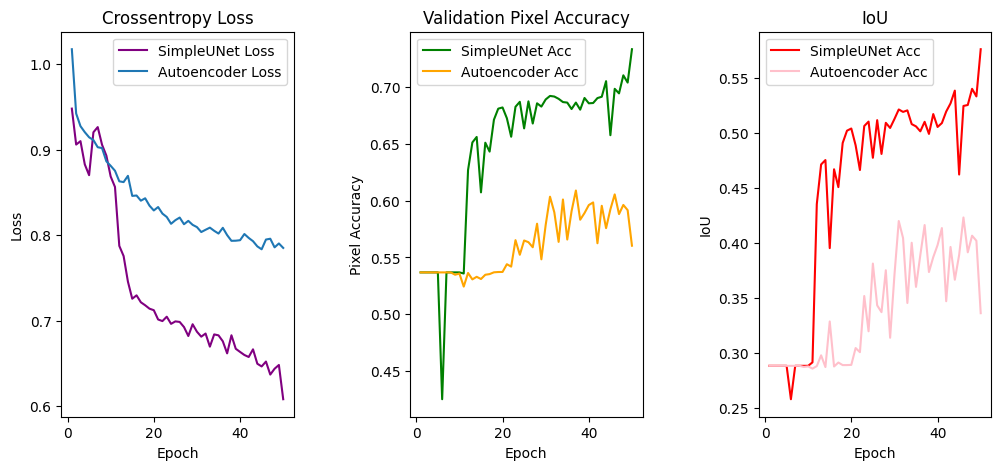

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.subplots_adjust(wspace=0.5)

# Loss
plt.subplot(1,3,1)
plt.plot(epochs_list, unet_losses, color="purple", label="SimpleUNet Loss")
plt.plot(epochs_list, ae_losses, label="Autoencoder Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Crossentropy Loss")
plt.legend()

# Pixel Accuracy
plt.subplot(1,3,2)
plt.plot(epochs_list, unet_accs, color="green", label="SimpleUNet Acc")
plt.plot(epochs_list, ae_accs, color="orange", label="Autoencoder Acc")
plt.xlabel("Epoch")
plt.ylabel("Pixel Accuracy")
plt.title("Validation Pixel Accuracy")
plt.legend()

# IoU
plt.subplot(1,3,3)
plt.plot(epochs_list, unet_iou, color="red", label="SimpleUNet Acc")
plt.plot(epochs_list, ae_iou, color="pink", label="Autoencoder Acc")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("IoU")
plt.legend()

plt.show()

plt.show()


* As expected, all models improved evaluation metrics with increasing epochs.

* Although both models display a decreasing CrossEntropyloss over more epochs, the U-Net loss is more drastic and generally stays significantly lower than the simple autoencoder. Therefore, the U-Net is making less segmentation errors.

* Both models display increasing pixel accuracy over epochs, but the simple U-Net achieves a pixel accuracy decently higher and faster than the autoencoder accuracy.

* Both models display increasing IoU over epoch, but the simple U-Net achieves a drastically higher IoU score, which indicates that it is decent at capturing edges and shapes.



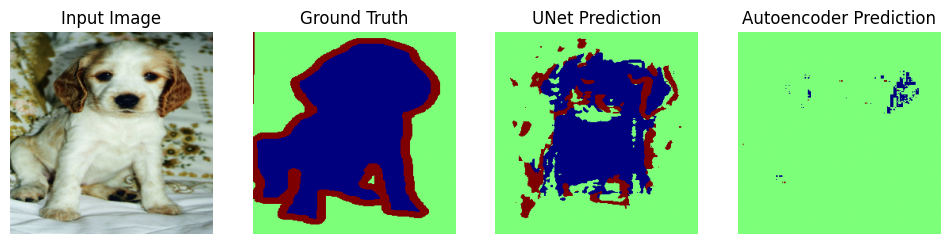

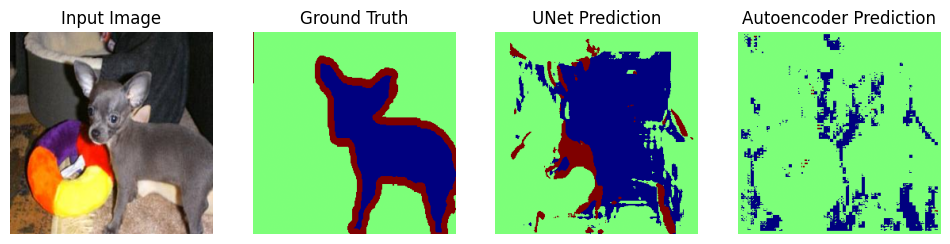

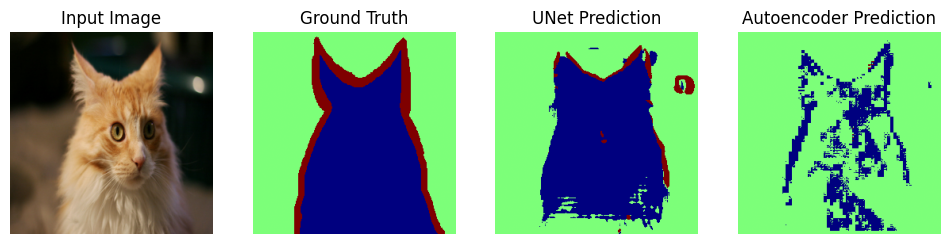

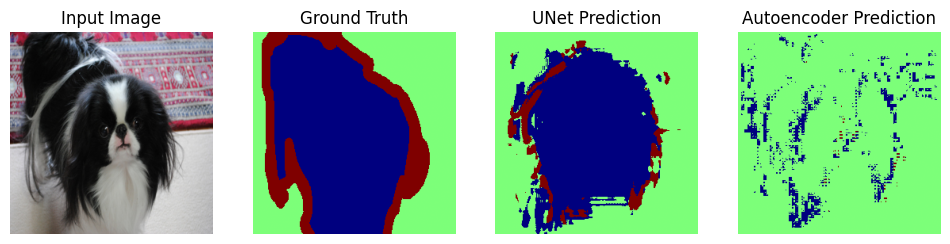

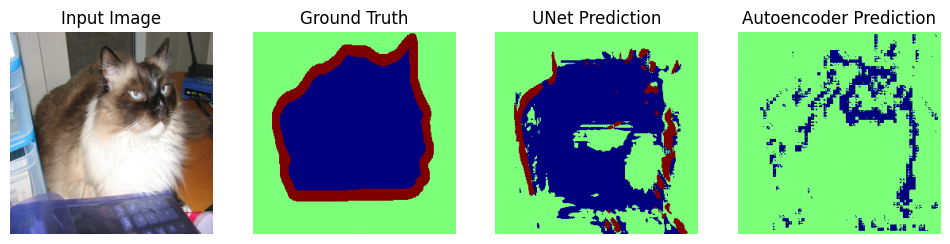

In [12]:
#https://docs.pytorch.org/vision/0.11/auto_examples/plot_visualization_utils.html?utm_source=chatgpt.com
#Utilizing the Pytorch docs and revision from ChatGPT, the actual images generated by the model can be compared to the ground truth.

import matplotlib.pyplot as plt

def show_predictions(model, loader, num_images=5):
    model.eval()
    images_shown = 0
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs_unet = unet_model(images)
            outputs_ae   = ae_model(images)

            # Get predicted class for each pixel
            pred_unet = outputs_unet.argmax(1).cpu()
            pred_ae   = outputs_ae.argmax(1).cpu()
            images_cpu = images.cpu()
            masks_cpu  = masks.cpu()

            for i in range(images.size(0)):
                if images_shown >= num_images:
                    return
                fig, axes = plt.subplots(1,4, figsize=(12,3))
                axes[0].imshow(images_cpu[i].permute(1,2,0))
                axes[0].set_title("Input Image")
                axes[0].axis("off")

                axes[1].imshow(masks_cpu[i], cmap="jet")
                axes[1].set_title("Ground Truth")
                axes[1].axis("off")

                axes[2].imshow(pred_unet[i], cmap="jet")
                axes[2].set_title("UNet Prediction")
                axes[2].axis("off")

                axes[3].imshow(pred_ae[i], cmap="jet")
                axes[3].set_title("Autoencoder Prediction")
                axes[3].axis("off")

                plt.show()
                images_shown += 1

# Show predictions on validation set
show_predictions(unet_model, val_loader, num_images=5)




* Visually, the simple U-Net is generally better at capturing edges and shapes, generating an image closer to the ground truth than the simple autoencoder.



### Parting Comments

U-Nets will generally perform better on image segmentation tasks than simple autoencoders as demonstrated visually in the workflow.

Pytorch has an smp tool that will allow you to easily make a more complex U-Net. This U-Net, using ResNet, a deep learning visual architecture, will generate a prediction image significantly closer to the ground truth. I highly recommend trying this tool.

### About the Author

Thank you for observing my workflow! I hope it was helpful. I hold a degree in biology and a certificate in data science and business analytics. Currently, I manage [Hello Maker Studio](https://exl.cns.utexas.edu/hello-maker-studio), a makerspace in the College of Natural Sciences at [The University of Texas at Austin](https://www.utexas.edu/).

Feel free to connect with me on [LinkedIn](www.linkedin.com/in/rhiannon-morris).



### About the Supervising Professor

Michael Pyrcz is a professor in the [Cockrell School of Engineering](https://cockrell.utexas.edu/faculty-directory/alphabetical/p), and the [Jackson School of Geosciences](https://www.jsg.utexas.edu/researcher/michael_pyrcz/), at [The University of Texas at Austin](https://www.utexas.edu/), where he researches and teaches subsurface, spatial data analytics, geostatistics, and machine learning. Michael is also,

* the principal investigator of the [Energy Analytics](https://fri.cns.utexas.edu/energy-analytics) freshmen research initiative and a core faculty in the Machine Learn Laboratory in the College of Natural Sciences, The University of Texas at Austin

* an associate editor for [Computers and Geosciences](https://www.sciencedirect.com/journal/computers-and-geosciences/about/editorial-board), and a board member for [Mathematical Geosciences](https://link.springer.com/journal/11004/editorial-board), the International Association for Mathematical Geosciences.

Michael has written over 70 [peer-reviewed publications](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en), a [Python package](https://pypi.org/project/geostatspy/) for spatial data analytics, co-authored a textbook on spatial data analytics, [Geostatistical Reservoir Modeling](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) and author of two recently released e-books, [Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) and [Applied Machine Learning in Python: a Hands-on Guide with Code](https://geostatsguy.github.io/MachineLearningDemos_Book/intro.html).

All of Michael’s university lectures are available on his [YouTube Channel](https://www.youtube.com/@GeostatsGuyLectures) with links to 100s of Python interactive dashboards and well-documented workflows in over 40 repositories on his [GitHub account](https://github.com/GeostatsGuy), to support any interested students and working professionals with evergreen content. To find out more about Michael’s work and shared educational resources visit his [Website](www.michaelpyrcz.com).

#### Want to Work Together?

I hope this content is helpful to those that want to learn more about subsurface modeling, data analytics and machine learning. Students and working professionals are welcome to participate.

* Want to invite me to visit your company for training, mentoring, project review, workflow design and / or consulting? I'd be happy to drop by and work with you!

* Interested in partnering, supporting my graduate student research or my Subsurface Data Analytics and Machine Learning consortium (co-PI is Professor John Foster)? My research combines data analytics, stochastic modeling and machine learning theory with practice to develop novel methods and workflows to add value. We are solving challenging subsurface problems!

* I can be reached at mpyrcz@austin.utexas.edu.

I'm always happy to discuss,

*Michael*

Michael Pyrcz, Ph.D., P.Eng. Professor, Cockrell School of Engineering and The Jackson School of Geosciences, The University of Texas at Austin

More Resources Available at: [Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)

